In [1]:
# Import Required Libraries

import warnings

warnings.filterwarnings("ignore")

import os

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from catboost import CatBoostRegressor

from lightgbm import LGBMRegressor

from xgboost import XGBRegressor

from sklearn.ensemble import (

    RandomForestRegressor,

    ExtraTreesRegressor

)

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score

)

In [2]:
# Set Display Options

pd.set_option(

    "display.max_columns",

    None

)

pd.set_option(

    "display.float_format",

    "{:.3f}".format

)

In [3]:
# Load Processed Datasets

X_train = pd.read_csv(

    "../data/processed/X_train.csv"

)

X_test = pd.read_csv(

    "../data/processed/X_test.csv"

)

y_train = pd.read_csv(

    "../data/processed/y_train.csv"

)

y_test = pd.read_csv(

    "../data/processed/y_test.csv"

)

In [4]:
# Dataset Verification

print(

    "Training Features :",

    X_train.shape

)

print(

    "Testing Features :",

    X_test.shape

)

print(

    "Training Target :",

    y_train.shape

)

print(

    "Testing Target :",

    y_test.shape

)

Training Features : (79913, 31)
Testing Features : (19979, 31)
Training Target : (79913, 1)
Testing Target : (19979, 1)


In [5]:
# Remove Identifier Columns

identifier_columns = [

    "Run",

    "Event"

]

X_train = X_train.drop(

    columns=identifier_columns,

    errors="ignore"

)

X_test = X_test.drop(

    columns=identifier_columns,

    errors="ignore"

)

print(

    "Identifier Columns Removed"

)

Identifier Columns Removed


In [6]:
# Convert Target Variables to Series

y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [7]:
# Load Best Model Information

best_model_summary = pd.read_csv(

    "../results/best_model_summary.csv"

)

best_model_name = best_model_summary.loc[

    0,

    "Model"

]

print(

    "Best Model :",

    best_model_name

)

Best Model : CatBoost


In [8]:
# Load Consensus Feature Importance

consensus_importance = pd.read_csv(

    "../results/consensus_feature_importance.csv"

)

display(

    consensus_importance.head()

)

,Feature,CatBoost,Permutation,SHAP,Consensus
0,Eta_Difference,1.000,1.000,1.000,1.000
1,Total_PT,0.997,0.934,0.720,0.884
2,Cos_Theta,0.361,0.734,0.765,0.620
3,Total_Energy,0.242,0.708,0.652,0.534
4,E1,0.183,0.320,0.359,0.287


In [9]:
# Identify Original Sensor Features

original_features = []

for feature in X_train.columns:

    if (
        not feature.startswith("Total_")
        and not feature.endswith("_Difference")
        and not feature.startswith("Momentum")
        and not feature.startswith("Charge_")
        and feature != "Cos_Theta"
    ):

        original_features.append(feature)

print("Original Sensor Features :", len(original_features))

display(
    pd.DataFrame({
        "Original Features": original_features
    })
)

Original Sensor Features : 16


,Original Features
0,E1
1,px1
2,py1
3,pz1
4,pt1
5,eta1
6,phi1
7,Q1
8,E2
9,px2


In [10]:
# Select Continuous Sensor Features

continuous_features = []

for feature in original_features:

    if X_train[feature].nunique() > 2:

        continuous_features.append(feature)

print("Continuous Sensor Features :", len(continuous_features))

display(
    pd.DataFrame({
        "Continuous Features": continuous_features
    })
)

Continuous Sensor Features : 14


,Continuous Features
0,E1
1,px1
2,py1
3,pz1
4,pt1
5,eta1
6,phi1
7,E2
8,px2
9,py2


In [11]:
# Load Selected Sensors

selected_features = pd.read_csv(

    "../results/selected_features.csv"

)

input_sensors = [

    feature

    for feature in selected_features["Feature"]

    if feature in continuous_features

]

print(

    "Input Sensors :",

    len(input_sensors)

)

print()

display(

    pd.DataFrame({

        "Input Sensors": input_sensors

    })

)

Input Sensors : 3



,Input Sensors
0,E1
1,pt1
2,pt2


In [12]:
# Select Redundant Sensors

redundant_sensors = [

    feature

    for feature in continuous_features

    if feature not in input_sensors

]

redundant_sensors = pd.DataFrame({

    "Feature": redundant_sensors

})

print(

    "Number of Redundant Sensors :",

    len(redundant_sensors)

)

display(

    redundant_sensors

)

Number of Redundant Sensors : 11


,Feature
0,px1
1,py1
2,pz1
3,eta1
4,phi1
5,E2
6,px2
7,py2
8,pz2
9,eta2


In [13]:
# Verify Selected Sensors

missing_features = [

    feature

    for feature in input_sensors

    if feature not in X_train.columns

]

if missing_features:

    raise ValueError(

        f"Missing Features: {missing_features}"

    )

print(

    "Selected Sensors Verified Successfully"

)

Selected Sensors Verified Successfully


In [14]:
# Initialize Prediction Model

if best_model_name == "CatBoost":

    model_class = CatBoostRegressor

    model_parameters = {

        "random_state": 42,

        "verbose": 0

    }

elif best_model_name == "LightGBM":

    model_class = LGBMRegressor

    model_parameters = {

        "random_state": 42

    }

elif best_model_name == "XGBoost":

    model_class = XGBRegressor

    model_parameters = {

        "random_state": 42,

        "verbosity": 0

    }

elif best_model_name == "Extra Trees":

    model_class = ExtraTreesRegressor

    model_parameters = {

        "random_state": 42,

        "n_jobs": -1

    }

elif best_model_name == "Random Forest":

    model_class = RandomForestRegressor

    model_parameters = {

        "random_state": 42,

        "n_jobs": -1

    }

else:

    raise ValueError(

        f"Unsupported Model: {best_model_name}"

    )

In [15]:
# Predict Redundant Sensors

prediction_results = []

best_predictions = None

best_actual = None

best_sensor = None

best_r2 = -np.inf

for target_sensor in redundant_sensors["Feature"]:

    selected_inputs = [

        feature

        for feature in input_sensors

        if feature != target_sensor

    ]

    X_train_sensor = X_train[

        selected_inputs

    ]

    X_test_sensor = X_test[

        selected_inputs

    ]

    y_train_sensor = X_train[

        target_sensor

    ]

    y_test_sensor = X_test[

        target_sensor

    ]

    model = model_class(

        **model_parameters

    )

    model.fit(

        X_train_sensor,

        y_train_sensor

    )

    predictions = model.predict(

        X_test_sensor

    )

    mae = mean_absolute_error(

        y_test_sensor,

        predictions

    )

    rmse = np.sqrt(

        mean_squared_error(

            y_test_sensor,

            predictions

        )

    )

    r2 = r2_score(

        y_test_sensor,

        predictions

    )

    prediction_results.append({

        "Sensor": target_sensor,

        "MAE": mae,

        "RMSE": rmse,

        "R²": r2

    })

    if r2 > best_r2:

        best_r2 = r2

        best_sensor = target_sensor

        best_actual = y_test_sensor

        best_predictions = predictions

print(

    "Redundant Sensor Prediction Completed"

)

Redundant Sensor Prediction Completed


In [16]:
# Create Prediction Results Table

prediction_results_df = pd.DataFrame(

    prediction_results

)

prediction_results_df = prediction_results_df.sort_values(

    by="R²",

    ascending=False

).reset_index(

    drop=True

)

display(

    prediction_results_df

)

,Sensor,MAE,RMSE,R²
0,E2,18.049,27.526,0.650
1,eta1,1.254,1.468,-0.004
2,phi2,1.567,1.812,-0.005
3,phi1,1.559,1.805,-0.007
4,eta2,1.584,1.748,-0.009
5,py1,9.231,13.669,-0.025
6,py2,8.845,13.344,-0.031
7,px1,9.223,13.796,-0.041
8,px2,8.842,13.297,-0.051
9,pz2,40.837,62.995,-0.051


In [17]:
# Display Best Predicted Sensor

print(

    "Best Predicted Sensor :",

    best_sensor

)

print(

    "Best R² Score :",

    round(best_r2, 3)

)

Best Predicted Sensor : E2
Best R² Score : 0.65


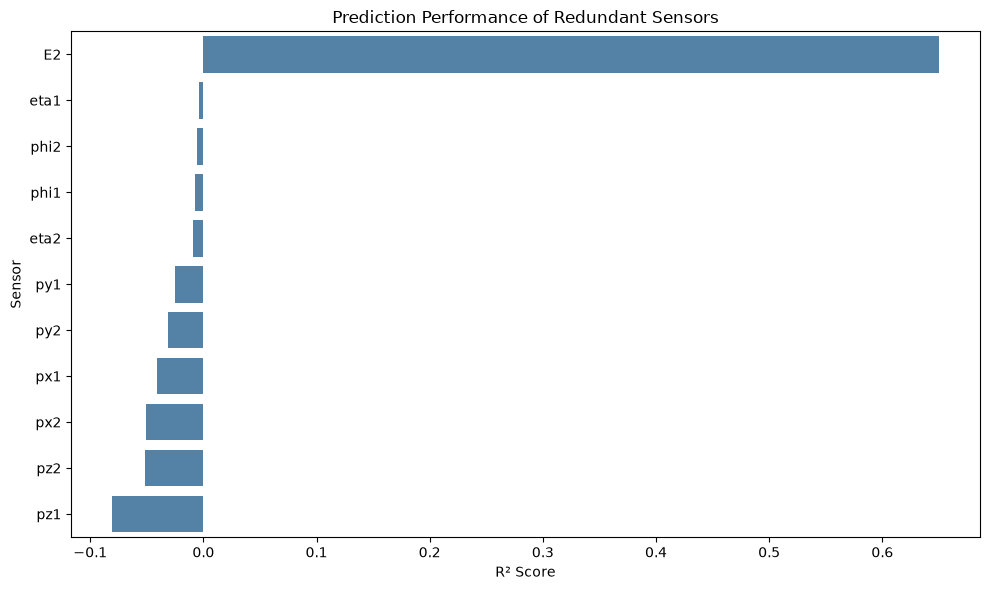

In [18]:
# Compare Sensor Prediction Performance

plt.figure(figsize=(10,6))

sns.barplot(

    data=prediction_results_df,

    x="R²",

    y="Sensor",

    color="steelblue"

)

plt.title(

    "Prediction Performance of Redundant Sensors"

)

plt.xlabel(

    "R² Score"

)

plt.ylabel(

    "Sensor"

)

plt.tight_layout()

plt.show()

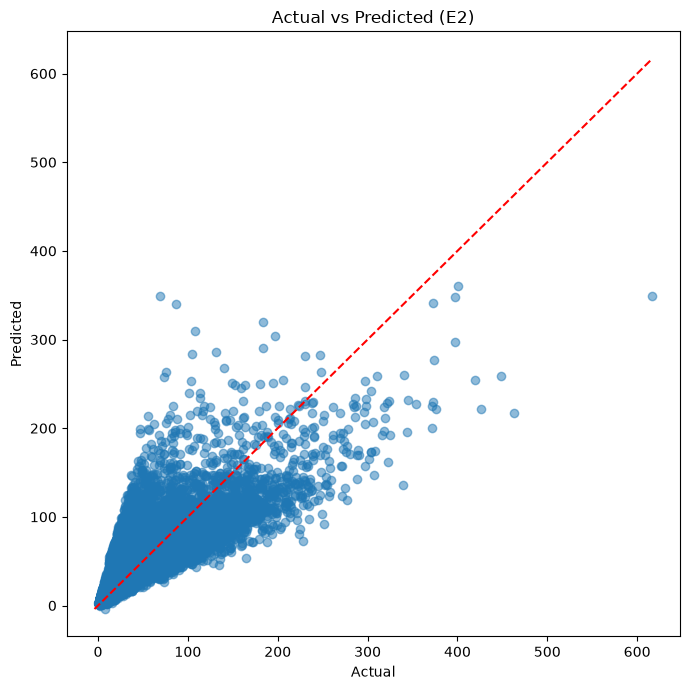

In [19]:
# Compare Actual and Predicted Values

plt.figure(figsize=(7,7))

plt.scatter(

    best_actual,

    best_predictions,

    alpha=0.5

)

minimum = min(

    best_actual.min(),

    best_predictions.min()

)

maximum = max(

    best_actual.max(),

    best_predictions.max()

)

plt.plot(

    [minimum, maximum],

    [minimum, maximum],

    color="red",

    linestyle="--"

)

plt.title(

    f"Actual vs Predicted ({best_sensor})"

)

plt.xlabel(

    "Actual"

)

plt.ylabel(

    "Predicted"

)

plt.tight_layout()

plt.show()

In [20]:
# Save Prediction Results

os.makedirs(

    "../results",

    exist_ok=True

)

prediction_results_df.to_csv(

    "../results/sensor_prediction_results.csv",

    index=False

)

print(

    "Prediction Results Saved Successfully"

)

Prediction Results Saved Successfully


In [21]:
# Save Predicted Sensors

pd.DataFrame({

    "Sensor": redundant_sensors["Feature"]

}).to_csv(

    "../results/predicted_sensors.csv",

    index=False

)

print(

    "Predicted Sensors Saved Successfully"

)

Predicted Sensors Saved Successfully
